# Lab 4 Plots and Calculations 

### Im adding in the footnotes from the lab handout here. The details in it are important. 

**********************************************************************************************************************
### Footnotes
The theoretical analysis has ignored any “end effects” for the neck of the Helmholtz resonator. The oscillating 
air continues to move outside the length of the neck (and not necessarily in a single direction). There is some 
math and experiment to back this up. The length correction for a flanged circular pipe is Leff = L + 8a/3π
while the length correction for an unflanged circular pipe is Leff = L + 0.6a where a is the radius. Don’t forget - pipes have two ends and length corrections add
**********************************************************************************************************************

Equation 3 in the lab handout is key to the plots and calculations. The equation is given as: $$(\frac{c^{2}}{4 \pi^{2}}A)T_{i}^{2} = \Delta x_{eff}(V-\Delta V_{i})$$

where $\Delta V_{i}$ is the change in volume and $T_{i}$ is the period for the i-th measurement. C is the speed of sound calculated during the experiment. A is the cross sectional area of the opening of the Helmholtz resonator. This theoretical relationship looks like the equation for a straight line!

         PHYSICAL PARAMETERS
  Speed of sound c     = 345.9 m/s
  Neck diameter        = 33.17 mm
  Neck radius a        = 16.5850 mm
  Neck length L        = 140.0 mm
  Cross-section area A = 8.641335e-04 m²
  Flask volume V       = fitted from data (see below)

  y values (×10⁻⁴ m⁴): [3.64658404 3.28517309 3.22677118 3.16889305 3.1115387  3.05470814
 2.99840137 2.94261837 2.88735916 2.7784121  2.67156017 2.67156017
 2.51521065 2.42366369 2.28952523 2.16396373 2.05120352 1.98226045
 1.96407467 2.08845504 1.9459727 ]
  x values (×10⁻⁶ m³): [   0.   50.  100.  150.  200.  250.  300.  350.  400.  450.  500.  550.
  600.  650.  700.  750.  800.  850.  900.  950. 1000.]

         LINEAR FIT RESULTS
  Slope            = -1.616723e-01 ± 6.269977e-03 m
  Intercept        = 3.468738e-04 m⁴
  R²               = 0.972217

  Δx_eff (slope)   = 161.672 ± 6.270 mm
  Δx_eff (intcpt)  = 161.672 mm  ← uses fitted V0

  Physical neck L  = 140.0 ± 0.5 mm

         LENGTH CORRECTIONS
  Physical L        

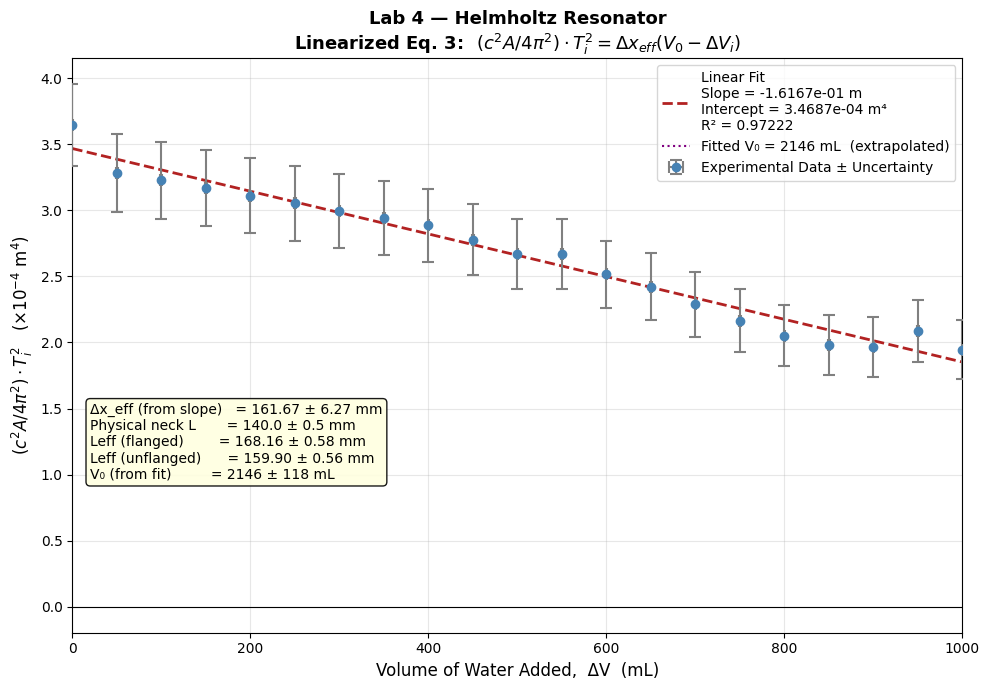

✅ Figure 1 saved.


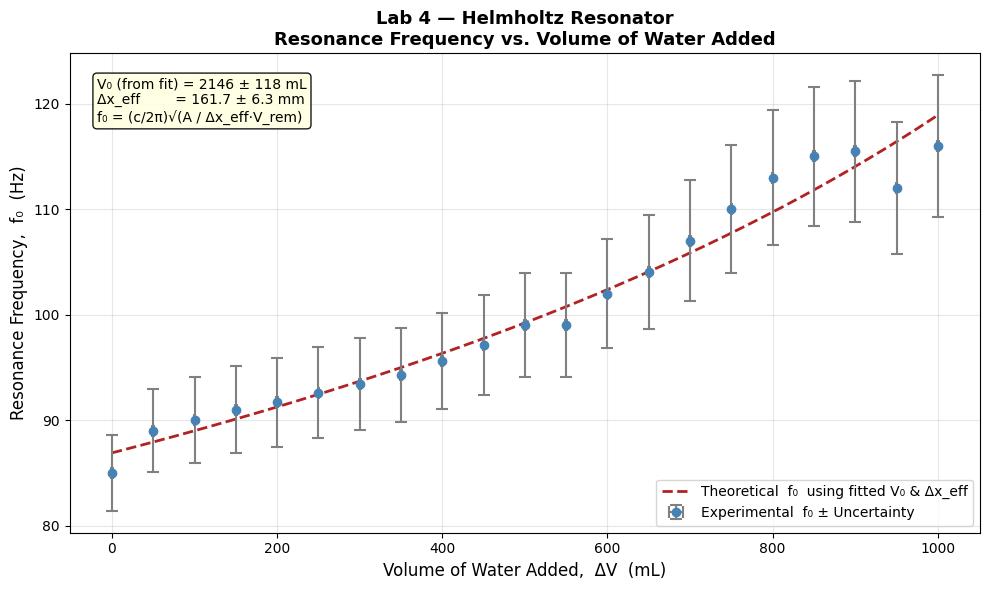

✅ Figure 2 saved.

🎉 All figures saved to: c:\Users\hogwi\OneDrive - University of Central Arkansas\Acoustics_ElectroMag\Spring-Acoustics---ElectroMag2\Acoustics\Lab_4\Images


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from pathlib import Path

# ============================================================
# PATHS
# ============================================================
base = Path(r"c:\Users\hogwi\OneDrive - University of Central Arkansas\Acoustics_ElectroMag\Spring-Acoustics---ElectroMag2\Acoustics\Lab_4")
img  = base / "Images"
img.mkdir(exist_ok=True)

# ============================================================
# LOAD DATA (drop empty trailing rows)
# ============================================================
df = pd.read_csv(base / "Lab_4_Data_Collection_CSV.csv",
                 usecols=range(8)).dropna(subset=['Trial #'])
df = df[df['Trial #'] != ''].copy()
df.columns = ['Trial', 'dV_mL', 'Freq_Hz', 'Period_s',
              'Temp_C', 'Neck_diam_mm', 'Neck_length_mm', 'c_ms']
df = df.astype({'Trial': int, 'dV_mL': float, 'Freq_Hz': float,
                'Period_s': float, 'c_ms': float})

# ============================================================
# CONSTANTS & UNIT CONVERSIONS
# ============================================================
c     = 345.9                          # m/s (speed of sound at 24.61°C)
d_m   = df['Neck_diam_mm'].iloc[0] / 1000.0   # neck diameter in m
a     = d_m / 2.0                      # neck radius in m
L_m   = df['Neck_length_mm'].iloc[0] / 1000.0 # physical neck length in m

A     = np.pi * a**2                   # cross-sectional area of neck (m²)
V_flask_mL = 1000.0                    # initial flask volume in mL
V_flask_m3 = V_flask_mL * 1e-6        # convert to m³

# Uncertainty estimates
dL_unc   = 0.5e-3    # ±0.5 mm uncertainty in neck length → m
da_unc   = 0.05e-3   # ±0.05 mm uncertainty in radius → m
dT_unc   = 0.5e-3    # ±0.5 ms uncertainty in period → s (oscilloscope)
dV_unc   = 1.0e-6    # ±1 mL uncertainty in volume → m³

print("=" * 55)
print("         PHYSICAL PARAMETERS")
print("=" * 55)
print(f"  Speed of sound c     = {c} m/s")
print(f"  Neck diameter        = {d_m*1000:.2f} mm")
print(f"  Neck radius a        = {a*1000:.4f} mm")
print(f"  Neck length L        = {L_m*1000:.1f} mm")
print(f"  Cross-section area A = {A:.6e} m²")
print(f"  Flask volume V       = fitted from data (see below)")

# ============================================================
# COMPUTE Y AND X FOR LINEAR FIT
# ============================================================
# y = (c²/4π²) * A * T²         [units: m³·s²/s² → m⁵? No...]
#
# Let's check units carefully:
# c² [m²/s²] * A [m²] * T² [s²] = m⁴   ← left side
# Δx_eff [m] * (V - ΔV) [m³]    = m⁴   ← right side ✅
#
# x = ΔV_i (change in volume, m³)
# y = (c²*A/4π²) * T²
# Equation: y = Δx_eff * V - Δx_eff * x
#           y = -Δx_eff * x + Δx_eff * V
# So slope = -Δx_eff  →  Δx_eff = -slope
# Intercept = Δx_eff * V

dV_m3 = df['dV_mL'].values * 1e-6     # ΔV in m³
T_s   = df['Period_s'].values          # period in s

y_vals = (c**2 * A / (4 * np.pi**2)) * T_s**2   # m⁴
x_vals = dV_m3                                    # m³

# Uncertainty in y: dy = (c²*A/4π²) * 2*T * dT
y_unc  = (c**2 * A / (4 * np.pi**2)) * 2 * T_s * dT_unc

print(f"\n  y values (×10⁻⁴ m⁴): {y_vals*1e4}")
print(f"  x values (×10⁻⁶ m³): {x_vals*1e6}")

# ============================================================
# LINEAR REGRESSION
# ============================================================
slope, intercept, r_val, p_val, slope_se = linregress(x_vals, y_vals)

# Δx_eff from slope: slope = -Δx_eff
dx_eff_from_slope = -slope
dx_eff_unc        = slope_se

# ⚠️ intercept = Δx_eff * V0  →  need V0 first from x-intercept
V0_m3  = -intercept / slope        # true flask air volume in m³
V0_mL  = V0_m3 * 1e6

# NOW compute Δx_eff from intercept using correct V0 (not hardcoded 1000 mL)
dx_eff_from_intercept = intercept / V0_m3   # ✅ uses fitted V0

print("\n" + "=" * 55)
print("         LINEAR FIT RESULTS")
print("=" * 55)
print(f"  Slope            = {slope:.6e} ± {slope_se:.6e} m")
print(f"  Intercept        = {intercept:.6e} m⁴")
print(f"  R²               = {r_val**2:.6f}")
print(f"\n  Δx_eff (slope)   = {dx_eff_from_slope*1000:.3f} ± {dx_eff_unc*1000:.3f} mm")
print(f"  Δx_eff (intcpt)  = {dx_eff_from_intercept*1000:.3f} mm  ← uses fitted V0")
print(f"\n  Physical neck L  = {L_m*1000:.1f} ± {dL_unc*1000:.1f} mm")

# ============================================================
# LENGTH CORRECTIONS (both ends of neck)
# ============================================================
# Flanged:   Leff = L + 2*(8a/3π)
# Unflanged: Leff = L + 2*(0.6a)
L_flanged   = L_m + 2 * (8 * a / (3 * np.pi))
L_unflanged = L_m + 2 * (0.6 * a)

# Uncertainty in Leff: add uncertainty in L and correction term
L_flanged_unc   = dL_unc + 2 * (8 * da_unc / (3 * np.pi))
L_unflanged_unc = dL_unc + 2 * (0.6 * da_unc)

print("\n" + "=" * 55)
print("         LENGTH CORRECTIONS")
print("=" * 55)
print(f"  Physical L            = {L_m*1000:.2f} ± {dL_unc*1000:.2f} mm")
print(f"  Leff (flanged)        = {L_flanged*1000:.2f} ± {L_flanged_unc*1000:.2f} mm")
print(f"  Leff (unflanged)      = {L_unflanged*1000:.2f} ± {L_unflanged_unc*1000:.2f} mm")
print(f"  Δx_eff (from fit)     = {dx_eff_from_slope*1000:.2f} ± {dx_eff_unc*1000:.2f} mm")

# Agreement check
def check_agreement(val1, unc1, val2, unc2, label):
    diff = abs(val1 - val2)
    combined = unc1 + unc2
    status = "✅ AGREE" if diff <= combined else "❌ DISAGREE"
    print(f"\n  {label}")
    print(f"    |{val1*1000:.2f} - {val2*1000:.2f}| = {diff*1000:.2f} mm  vs  "
          f"combined unc = {combined*1000:.2f} mm  →  {status}")

print("\n" + "=" * 55)
print("         AGREEMENT CHECKS")
print("=" * 55)
check_agreement(dx_eff_from_slope, dx_eff_unc, L_m, dL_unc,
                "Δx_eff vs Physical L")
check_agreement(dx_eff_from_slope, dx_eff_unc, L_flanged, L_flanged_unc,
                "Δx_eff vs Leff (flanged)")
check_agreement(dx_eff_from_slope, dx_eff_unc, L_unflanged, L_unflanged_unc,
                "Δx_eff vs Leff (unflanged)")

# ============================================================
# EXTRACT TRUE FLASK VOLUME FROM X-INTERCEPT OF LINEAR FIT
# ============================================================
# At y = 0:  0 = slope * x + intercept  →  x_intercept = -intercept / slope = V0
V0_m3  = -intercept / slope        # true flask air volume in m³
V0_mL  = V0_m3 * 1e6              # convert to mL

# Uncertainty in V0 via error propagation:
# V0 = -intercept / slope
# δV0 = V0 * sqrt((δintercept/intercept)² + (δslope/slope)²)
# estimate δintercept ≈ slope_se * V0  (since intercept = Δx_eff * V0)
intercept_se = slope_se * V0_m3
V0_unc_m3 = V0_m3 * np.sqrt(
    (intercept_se / intercept)**2 +
    (slope_se     / slope)**2
)

print("\n" + "=" * 55)
print("         FLASK VOLUME FROM X-INTERCEPT")
print("=" * 55)
print(f"  V0 from fit           = {V0_mL:.1f} ± {V0_unc_m3*1e6:.1f} mL")
print(f"  V0 from fit           = {V0_m3*1e3:.4f} ± {V0_unc_m3*1e3:.4f} L")
print(f"  V0 from fit (m³)      = {V0_m3:.4e} m³")               # ← added SI units
print(f"  Professor estimate    = ~2000 mL (2L flask)")
diff_pct = abs(V0_mL - 2000) / 2000 * 100
print(f"  Difference from 2L    = {abs(V0_mL-2000):.0f} mL  ({diff_pct:.1f}%)")

# ============================================================
# FIT LINE FOR PLOTTING — only over data range (0 to 1000 mL)
# ============================================================
x_fit = np.linspace(0, 1000e-6, 300)   # only plot fit over data range
y_fit = slope * x_fit + intercept

# ============================================================
# PLOT 1: Main Linear Plot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))

ax.errorbar(x_vals * 1e6, y_vals * 1e4,
            xerr=dV_unc * 1e6, yerr=y_unc * 1e4,
            fmt='o', color='steelblue', ecolor='gray',
            elinewidth=1.5, capsize=4, capthick=1.5,
            markersize=6, zorder=5, label='Experimental Data ± Uncertainty')
ax.plot(x_fit * 1e6, y_fit * 1e4,
        '--', color='firebrick', linewidth=2,
        label=f'Linear Fit\n'
              f'Slope = {slope:.4e} m\n'
              f'Intercept = {intercept:.4e} m⁴\n'
              f'R² = {r_val**2:.5f}')

# Mark V0 as vertical dashed line even though it's outside the plot range
ax.axvline(x=V0_mL, color='purple', linestyle=':', linewidth=1.5,
           label=f'Fitted V₀ = {V0_mL:.0f} mL  (extrapolated)')
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

# ── Limit x-axis to 0–1000 mL ──
ax.set_xlim(0, 1000)

ax.set_xlabel('Volume of Water Added,  ΔV  (mL)', fontsize=12)
ax.set_ylabel(r'$(c^2 A / 4\pi^2)\cdot T_i^2$   (×10$^{-4}$ m$^4$)', fontsize=12)
ax.set_title('Lab 4 — Helmholtz Resonator\n'
             r'Linearized Eq. 3:  $(c^2 A / 4\pi^2)\cdot T_i^2 = \Delta x_{eff}(V_0 - \Delta V_i)$',
             fontsize=13, fontweight='bold')

# ── Moved annotation box LEFT to avoid overlapping fit label ──
ax.text(0.02, 0.40,
        f'Δx_eff (from slope)   = {dx_eff_from_slope*1000:.2f} ± {dx_eff_unc*1000:.2f} mm\n'
        f'Physical neck L       = {L_m*1000:.1f} ± {dL_unc*1000:.1f} mm\n'
        f'Leff (flanged)        = {L_flanged*1000:.2f} ± {L_flanged_unc*1000:.2f} mm\n'
        f'Leff (unflanged)      = {L_unflanged*1000:.2f} ± {L_unflanged_unc*1000:.2f} mm\n'
        f'V₀ (from fit)         = {V0_mL:.0f} ± {V0_unc_m3*1e6:.0f} mL',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(img / "Fig1_Helmholtz_Linear.png", dpi=150)
plt.show()
print("✅ Figure 1 saved.")

# ============================================================
# PLOT 2: Resonance Frequency vs Volume of Water Added
# ============================================================
# Use V0_m3 from fit — NOT the hardcoded 1000 mL assumption!
# Exclude any trial where dV >= V0 (no air left → unphysical)
df_plot = df[df['dV_mL'] < V0_mL].copy()
dV_plot = df_plot['dV_mL'].values * 1e-6   # m³

V_remaining = V0_m3 - dV_plot              # ✅ correct remaining air volume

# Theoretical points at each measurement
f_theory = (c / (2 * np.pi)) * np.sqrt(A / (dx_eff_from_slope * V_remaining))

# Smooth theoretical curve
dV_smooth = np.linspace(0, df_plot['dV_mL'].max(), 300) * 1e-6
V_smooth  = V0_m3 - dV_smooth
f_smooth  = (c / (2 * np.pi)) * np.sqrt(A / (dx_eff_from_slope * V_smooth))

# Frequency uncertainty: f = 1/T  →  δf = f² * δT
f_unc = df_plot['Freq_Hz'].values**2 * dT_unc

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(df_plot['dV_mL'], df_plot['Freq_Hz'],
            xerr=1.0, yerr=f_unc,
            fmt='o', color='steelblue', ecolor='gray',
            elinewidth=1.5, capsize=4, capthick=1.5,
            markersize=6, zorder=5,
            label='Experimental  f₀ ± Uncertainty')
ax.plot(dV_smooth * 1e6, f_smooth,
        '--', color='firebrick', linewidth=2,
        label=f'Theoretical  f₀  using fitted V₀ & Δx_eff')

ax.set_xlabel('Volume of Water Added,  ΔV  (mL)', fontsize=12)
ax.set_ylabel('Resonance Frequency,  f₀  (Hz)', fontsize=12)
ax.set_title('Lab 4 — Helmholtz Resonator\n'
             'Resonance Frequency vs. Volume of Water Added',
             fontsize=13, fontweight='bold')

ax.text(0.03, 0.95,
        f'V₀ (from fit) = {V0_mL:.0f} ± {V0_unc_m3*1e6:.0f} mL\n'
        f'Δx_eff        = {dx_eff_from_slope*1000:.1f} ± {dx_eff_unc*1000:.1f} mm\n'
        f'f₀ = (c/2π)√(A / Δx_eff·V_rem)',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(img / "Fig2_Freq_vs_Volume.png", dpi=150)
plt.show()
print("✅ Figure 2 saved.")

print(f"\n🎉 All figures saved to: {img}")

### Full cell output from above

=======================================================
         PHYSICAL PARAMETERS
=======================================================
  Speed of sound c     = 345.9 m/s
  Neck diameter        = 33.17 mm
  Neck radius a        = 16.5850 mm
  Neck length L        = 140.0 mm
  Cross-section area A = 8.641335e-04 m²
  Flask volume V       = fitted from data (see below)

  y values (×10⁻⁴ m⁴): [3.64658404 3.28517309 3.22677118 3.16889305 3.1115387  3.05470814
 2.99840137 2.94261837 2.88735916 2.7784121  2.67156017 2.67156017
 2.51521065 2.42366369 2.28952523 2.16396373 2.05120352 1.98226045
 1.96407467 2.08845504 1.9459727 ]
  x values (×10⁻⁶ m³): [   0.   50.  100.  150.  200.  250.  300.  350.  400.  450.  500.  550.
  600.  650.  700.  750.  800.  850.  900.  950. 1000.]

=======================================================
         LINEAR FIT RESULTS
=======================================================
  Slope            = -1.616723e-01 ± 6.269977e-03 m
  Intercept        = 3.468738e-04 m⁴
  R²               = 0.972217

  Δx_eff (slope)   = 161.672 ± 6.270 mm
  Δx_eff (intcpt)  = 161.672 mm  ← uses fitted V0

  Physical neck L  = 140.0 ± 0.5 mm

=======================================================
         LENGTH CORRECTIONS
=======================================================
  Physical L            = 140.00 ± 0.50 mm
  Leff (flanged)        = 168.16 ± 0.58 mm
  Leff (unflanged)      = 159.90 ± 0.56 mm
  Δx_eff (from fit)     = 161.67 ± 6.27 mm

=======================================================
         AGREEMENT CHECKS
=======================================================

  Δx_eff vs Physical L
    |161.67 - 140.00| = 21.67 mm  vs  combined unc = 6.77 mm  →  ❌ DISAGREE

  Δx_eff vs Leff (flanged)
    |161.67 - 168.16| = 6.48 mm  vs  combined unc = 6.85 mm  →  ✅ AGREE

  Δx_eff vs Leff (unflanged)
    |161.67 - 159.90| = 1.77 mm  vs  combined unc = 6.83 mm  →  ✅ AGREE

=======================================================
         FLASK VOLUME FROM X-INTERCEPT
=======================================================
  V0 from fit           = 2145.5 ± 117.7 mL
  V0 from fit           = 2.1455 ± 0.1177 L
  V0 from fit (m³)      = 2.1455e-03 m³
  Professor estimate    = ~2000 mL (2L flask)
  Difference from 2L    = 146 mL  (7.3%)